# 17) LLM suggestions for the RPA task with an editable graph

This notebook demonstrates an LLM-assisted RPA search workflow using reusable graph objects from `RL4CRN.llm`.  The graph is small on purpose: a **decider** chooses a proposal strategy and a **writer** emits CRN candidates in the standard JSON format.  The CRNs are then validated and scored through the same RL4CRN actuator, stepper, and task reward used by reinforcement learning.

This version uses DeepSeek Harness as an on-demand, separate-process backend. Each graph round gets an isolated run workspace with its task, exact CRN output contract, raw model calls, parsed candidates, and evaluator results. Set `BACKEND = "fake"` for a local smoke test without model calls.


## 1) Imports, backend, and logging options

Comet logging is optional.  When enabled, LLM metrics use the prefix `LLM/...`, while the RL trainer already logs metrics such as `Loss: Batch Best`.  This makes the two sources visually separable in Comet panels.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)
from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.default_tasks.TrackingTaskKind import TrackingTaskKind
from RL4CRN.utils.library_builders import build_MAK_library
from RL4CRN.llm import (
    DeciderWriterCRNGraph,
    HarnessDeciderWriterCRNGraph,
    HarnessLLMClient,
    LLMCandidateEvaluator,
    LLMGenerationConfig,
    LLMGraphNode,
    LLMGraphSpec,
    MMC2_RPA_TASK_PROMPT,
    plot_llm_evaluations,
)

BACKEND = "harness"  # choices: "fake", "harness"
USE_COMET = True

# Standalone graph round controls. The same count is reused below when the graph is attached to RL.
LLM_NUM_CANDIDATES = 10

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "apps" else Path.cwd()


def _load_env_file(path):
    if not path.exists():
        return
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and value:
            os.environ.setdefault(key, value)


def _load_vscode_terminal_env(path):
    if not path.exists():
        return
    try:
        settings = json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        return
    env_blocks = [
        settings.get("terminal.integrated.env.linux", {}),
        settings.get("terminal.integrated.env.osx", {}),
        settings.get("terminal.integrated.env.windows", {}),
    ]
    for block in env_blocks:
        if not isinstance(block, dict):
            continue
        for key, value in block.items():
            if value:
                os.environ.setdefault(str(key), str(value))


_load_env_file(REPO_ROOT / ".env")
_load_vscode_terminal_env(REPO_ROOT / ".vscode" / "settings.json")


def require_env(name):
    value = os.environ.get(name)
    if not value:
        raise RuntimeError(
            f"Set {name} before running notebook 17. Put it in {REPO_ROOT / '.env'} "
            "or in .vscode/settings.json, then restart the notebook kernel."
        )
    return value

DSH_HOME = Path(os.environ.get("DSH_HOME", Path.home() / "ai-workspaces/deepseek-test/.dsh-home"))

OUTPUT_DIR = REPO_ROOT / "comparisons" / "llm_rpa_decider_writer"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HARNESS_RUNS_DIR = Path.home() / "ai-workspaces/deepseek-test/crn-runs"

print("backend:", BACKEND)
print("Harness state:", DSH_HOME)
print("output dir:", OUTPUT_DIR)


backend: harness
Harness state: /local0/home/rossin/ai-workspaces/deepseek-test/.dsh-home
output dir: /local0/rossin/git/GenAI-Net/comparisons/llm_rpa_decider_writer


## 2) Optional Comet experiment

This analysis is configured with `USE_COMET = True`. Set `COMET_API_KEY` and `COMET_WORKSPACE` before running. Configure the DeepSeek API key only in the Harness UI; the notebook does not read or store it. The LLM graph logs:

- `LLM/Valid Count`
- `LLM/Invalid Count`
- `LLM/Loss Best`
- `LLM/Loss Average`
- `LLM/Loss Worst`
- `LLM/Loss Candidate`

These names are intentionally distinct from the RL trainer metrics (`Loss: ...`, `Entropy: ...`, `Risk`, etc.).


In [2]:
logger = None
if USE_COMET:
    from datetime import datetime
    from pytorch_lightning.loggers import CometLogger

    comet_logger = CometLogger(
        api_key=require_env("COMET_API_KEY"),
        project="RPA_LLM_DeciderWriter",
        workspace=require_env("COMET_WORKSPACE"),
        name=f"RPA_LLM_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}",
    )
    logger = comet_logger.experiment

print("Comet logging:", "enabled" if logger is not None else "disabled")


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/redsnic/rpa-llm-deciderwriter/2aa057da70fb49868b92a4e0cd07f122



Comet logging: enabled


## 3) Build the RPA task

This reproduces the RPA setup from notebook 04 in a smaller evaluation configuration suitable for interactive LLM suggestions.

In [ ]:
cfg = Configurator.preset("paper")

# Match notebook 04_RPA.ipynb exactly for the RPA task/training setup.
cfg.solver.algorithm = "CVODE"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10

cfg.train.max_added_reactions = 5
cfg.train.epochs = 101
cfg.train.render_every = 5
cfg.train.seed = 0
cfg.train.hall_of_fame_size = 50

# Dynamic exact-topology exclusion. Set M=0 to disable completely.
# Here, every 5 epochs, the best HoF topology is archived and future repeats get a high loss.
cfg.train.forbidden_topology_m = 1
cfg.train.forbidden_topology_every = 5
cfg.train.forbidden_topology_loss = 1e9
cfg.train.forbidden_topology_start_epoch = 0
# Try IPOPT refinement before archiving. If IPOPT fails/unavailable, store only below threshold.
cfg.train.forbidden_threshold = 0.001
cfg.train.forbidden_optimize_with_ipopt = True
cfg.train.forbidden_ipopt_maxiter = 100
cfg.train.forbidden_ipopt_log_min = -18.0
cfg.train.forbidden_ipopt_log_max = 6.0

# Notebook 04 uses the preset batch rule rather than a forced batch/CPU count.
# Effective batch size is batch_multiplier * detected CPU count unless overridden.
cfg.train.batch_size = None
cfg.train.n_cpus = None

cfg.render.n_best = 50
cfg.render.disregarded_percentage = 0.9
cfg.render.mode = {
    "style": "logger",
    "task": "transients",
    "format": "image",
    "topology": True,
}

species_labels = ["X_1", "X_2", "X_3"]
crn, species_labels = build_simple_IOCRN(
    species=species_labels,
    production_input_map={"X_1": "u_1"},
    degradation_input_map={"X_3": "u_2"},
    dilution_map={},
    output_species="X_3",
    solver=cfg.solver,
)

library_components = build_MAK_library(crn, species_labels, order=2)
library, M, K, masks = library_components

task = make_task(
    template_crn=crn,
    library_components=library_components,
    kind="tracking",
    species_labels=species_labels,
    params={
        "t_f": 100,
        "n_t": 1000,
        "ic": ("constant", 0.01),
        "weights": "transient",
        "u_values": [0.5, 1.0, 1.5],
        "target": lambda u_1: u_1,
    },
)

print_task_summary(task)
print("library size:", len(library))
print("reaction budget:", cfg.train.max_added_reactions)
print("forbidden topology M:", cfg.train.forbidden_topology_m)
print("forbidden topology cadence:", cfg.train.forbidden_topology_every)
print("forbidden threshold:", cfg.train.forbidden_threshold)
print("forbidden IPOPT enabled:", cfg.train.forbidden_optimize_with_ipopt)


Task: tracking
time_horizon: (1000,) [0..100.0]
num scenarios: 9
first 3 u: [array([0.5, 0.5], dtype=float32), array([0.5, 1. ], dtype=float32), array([0.5, 1.5], dtype=float32)]

library size: 91
reaction budget: 5
forbidden topology M: 1
forbidden topology cadence: 5
forbidden threshold: 100.0
forbidden IPOPT enabled: True


## 4) Build the standard RL interfaces

The LLM path uses the same `Session` objects as RL.  Candidate CRNs are not manually constructed in the notebook; they are passed through `LLMCandidateEvaluator`, which validates the IDs, parameter vector sizes, duplicate reactions, and then runs the normal simulator/reward path.

In [4]:
trainer = make_session_and_trainer(cfg, task, logger=logger)
session = trainer.s

evaluator = LLMCandidateEvaluator.from_session(
    session,
    min_parameter_value=0.1,
    max_parameter_value=50.0,
    enforce_parameter_bounds=True,
    forbidden_reaction_ids=[session.library.find_zero_reaction()],
    require_full_budget=True,
    require_unique_reactions=True,
)

print("Evaluator ready")
print(" - require full budget:", evaluator.require_full_budget)
print(" - require unique reactions:", evaluator.require_unique_reactions)

Evaluator ready
 - require full budget: True
 - require unique reactions: True


## 5) Backend factory

A backend only needs two methods: `generate_text` for graph reasoning nodes and `generate_json` for writer nodes.  The fake backend returns valid-shape candidates and is useful for testing the full plumbing.

In [5]:
class FakeRPAClient:
    def __init__(self, library, max_added_reactions):
        self.library = library
        self.max_added_reactions = int(max_added_reactions)
        self.text_prompts = []
        self.json_prompts = []

    def generate_text(self, prompt, generation_config=None):
        self.text_prompts.append(prompt)
        return json.dumps(
            {
                "strategy": "Propose diverse feed-forward and feedback motifs involving X_3 while preserving RPA-like buffering.",
                "constraints": ["exact budget", "unique IDs", "positive finite parameters", "library-only reactions"],
            },
            indent=2,
        )

    def generate_json(self, prompt, generation_config=None):
        self.json_prompts.append(prompt)
        candidates = []
        for offset in range(4):
            reaction_ids = []
            probe = offset * 7
            while len(reaction_ids) < self.max_added_reactions:
                rid = int((probe + 3 * len(reaction_ids)) % len(self.library))
                probe += 1
                if rid not in reaction_ids:
                    reaction_ids.append(rid)

            parameter_values = []
            for j, rid in enumerate(reaction_ids):
                n_params = int(self.library.get_reaction(rid).num_parameters)
                parameter_values.append([float(0.15 + 0.2 * (offset + 1) + 0.05 * j)] * n_params)
            candidates.append(
                {
                    "reasoning": f"fake RPA candidate {offset}: graph/evaluator smoke test",
                    "reaction_ids": reaction_ids,
                    "parameter_values": parameter_values,
                }
            )
        return {"candidates": candidates}


def make_llm_client(backend):
    if backend == "fake":
        return FakeRPAClient(library, cfg.train.max_added_reactions)
    if backend == "harness":
        return HarnessLLMClient(workspace_root=HARNESS_RUNS_DIR, dsh_home=DSH_HOME)
    raise ValueError(f"Unknown backend: {backend!r}")


client = make_llm_client(BACKEND)
print("client:", type(client).__name__)


client: HarnessLLMClient


## 6) Define the graph explicitly

The graph implementation lives in `RL4CRN.llm.graphs`, but all graph-editable pieces are exposed here.  To change the graph:

- edit `DECIDER_PROMPT_TEMPLATE` to change the planning role;
- edit `WRITER_PROMPT_TEMPLATE` to change the JSON-producing role;
- edit `GRAPH_EDGES` to add or remove conceptual connections;
- add more `LLMGraphNode` objects if you want additional roles such as critic, repairer, or topology checker.

Only the node named by `writer_node` is expected to return candidate JSON.  Other roles can return free text.

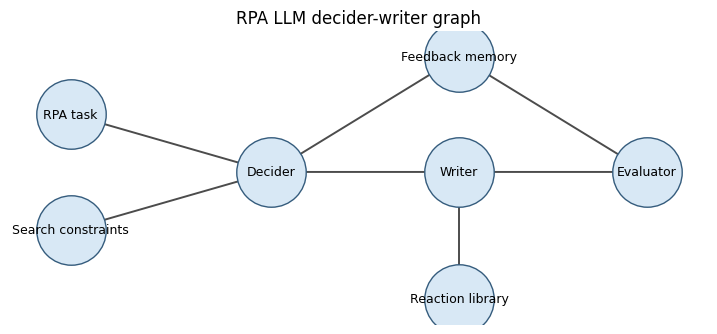

In [6]:
DECIDER_PROMPT_TEMPLATE = """
DECIDER ROLE
Choose a concise CRN proposal strategy for the RPA task below.
Respect these hard constraints:
- exactly {max_added_reactions} reactions;
- use only reaction IDs from the current library;
- no duplicate reaction IDs;
- every parameter must be positive and finite;
- every parameter vector must have the length required by its reaction.

Task:
{task_description}

Recent LLM feedback:
{feedback_text}

Best previous LLM candidates:
{llm_best_text}

Return a short JSON object with keys strategy and constraints.
"""

WRITER_PROMPT_TEMPLATE = """
{task_description}

Decider strategy and constraints:
{decision}

Generate candidates that obey every hard constraint. Prefer mechanistically diverse motifs.
"""

GRAPH_EDGES = [
    ("RPA task", "Decider"),
    ("Search constraints", "Decider"),
    ("Feedback memory", "Decider"),
    ("Decider", "Writer"),
    ("Reaction library", "Writer"),
    ("Writer", "Evaluator"),
    ("Evaluator", "Feedback memory"),
]

graph_spec = LLMGraphSpec(
    nodes=[
        LLMGraphNode("RPA task", "context", "Task context is supplied by this notebook."),
        LLMGraphNode("Search constraints", "context", "Exact budget, no duplicates, positive parameters."),
        LLMGraphNode(
            "Decider",
            "text",
            DECIDER_PROMPT_TEMPLATE,
            LLMGenerationConfig(temperature=0.2, response_mime_type="text/plain"),
        ),
        LLMGraphNode(
            "Writer",
            "json",
            WRITER_PROMPT_TEMPLATE,
            LLMGenerationConfig(temperature=0.7, max_output_tokens=8192),
        ),
        LLMGraphNode("Reaction library", "context", "The writer receives the ID-indexed library."),
        LLMGraphNode("Evaluator", "tool", "Runs candidate validation and RPA loss evaluation."),
        LLMGraphNode("Feedback memory", "memory", "Stores recent LLM outcomes."),
    ],
    edges=GRAPH_EDGES,
    decider_node="Decider",
    writer_node="Writer",
    title="RPA LLM decider-writer graph",
)

graph_type = HarnessDeciderWriterCRNGraph if BACKEND == "harness" else DeciderWriterCRNGraph
proposal_graph = graph_type(
    client=client,
    evaluator=evaluator,
    spec=graph_spec,
    comet_logger=logger,
    metric_prefix="LLM",
    transcript_jsonl_path=OUTPUT_DIR / "notebook17_llm_graph_messages.jsonl",
)

proposal_graph.draw();

## 7) Optional standalone LLM proposal round

For the prepared analysis this is disabled, so the only LLM calls happen inside the RL loop at the configured cadence.  Set `RUN_STANDALONE_LLM_ROUND = True` only when debugging the graph prompts or the candidate parser before training.


In [7]:
task_description = MMC2_RPA_TASK_PROMPT

RUN_STANDALONE_LLM_ROUND = False
result = None

if RUN_STANDALONE_LLM_ROUND:
    jsonl_path = OUTPUT_DIR / "notebook17_rpa_decider_writer_candidates.jsonl"
    transcript_path = OUTPUT_DIR / "notebook17_llm_graph_messages.jsonl"
    result = proposal_graph.run_round(
        task_description=task_description,
        num_candidates=LLM_NUM_CANDIDATES,
        hall_of_fame_iter=session.mult_env.hall_of_fame,
        add_to_hall_of_fame=session.mult_env.hall_of_fame,
        jsonl_path=jsonl_path,
        logger=logger,
        step=0,
    )

    print("Decision:")
    print(result.decision)
    print()
    print("Parsed candidates:", len(result.candidates))
    print("Logged candidate JSONL to:", jsonl_path)
    print("Logged graph-message JSONL to:", transcript_path)

    for i, evaluation in enumerate(result.evaluations):
        print(f"#{i}: valid={evaluation.valid} | loss={evaluation.loss} | message={evaluation.message}")
else:
    print("Standalone LLM round skipped. The RL loop will call the graph at the configured cadence.")


Standalone LLM round skipped. The RL loop will call the graph at the configured cadence.


## 8) Plot standalone LLM losses, if available

This plot is only produced when `RUN_STANDALONE_LLM_ROUND = True`.  During the actual RL analysis, LLM candidate losses are logged directly to Comet under the `LLM/` prefix.


In [8]:
if result is None:
    print("No standalone LLM result to plot.")
else:
    fig, ax = plt.subplots(figsize=(6, 3.2))
    plot_llm_evaluations(result.evaluations, ax=ax, title="RPA LLM suggestion losses")
    plt.tight_layout()

    if logger is not None and hasattr(logger, "log_figure"):
        logger.log_figure(figure_name="LLM/RPA suggestion losses", figure=fig, step=0)

    plt.show()


No standalone LLM result to plot.


## 9) Inspect the best accepted suggestion

In [9]:
if result is None:
    print("No standalone LLM result to inspect.")
else:
    valid = [ev for ev in result.evaluations if ev.valid]
    valid = sorted(valid, key=lambda ev: float(ev.loss))

    if valid:
        best = valid[0]
        print("Best LLM loss:", best.loss)
        print("Reaction IDs:", best.candidate.reaction_ids)
        print("Parameters:", best.candidate.parameter_values)
        print("Source tag:", best.env.state.last_task_info.get("source"))
        print()
        print("CRN:")
        print(best.env.state)
    else:
        print("No valid candidates. Inspect messages above and the writer prompt below.")


No standalone LLM result to inspect.


## 10) Optional: call the LLM graph from inside the RL loop

The trainer can call the same graph every `LLM_EVERY_EPOCHS` epochs. The call happens after the RL batch has been evaluated and before `agent.update(...)`, so valid LLM candidates are inserted into the Hall of Fame in time for self-imitation learning (SIL). Comet metrics from this path use the `LLM/` prefix, while the usual RL losses keep their existing names.


In [ ]:
LLM_EVERY_EPOCHS = 5
LLM_START_EPOCH = 0
LLM_STOP_EPOCH = None
RUN_RL_WITH_LLM = True
RL_EPOCHS_TO_RUN = cfg.train.epochs

trainer.configure_llm_graph(
    proposal_graph,
    every=LLM_EVERY_EPOCHS,
    task_description=task_description,
    num_candidates=LLM_NUM_CANDIDATES,
    start_epoch=LLM_START_EPOCH,
    stop_epoch=LLM_STOP_EPOCH,
    add_to_hall_of_fame=True,
    jsonl_path=OUTPUT_DIR / "notebook17_llm_inside_rl_loop_candidates.jsonl",
)

print(
    f"Configured LLM-in-RL hook: every {LLM_EVERY_EPOCHS} epochs, "
    f"{LLM_NUM_CANDIDATES} proposed CRNs per LLM generation round."
)
print("Local LLM candidate log:", OUTPUT_DIR / "notebook17_llm_inside_rl_loop_candidates.jsonl")
print("Local LLM graph-message log:", OUTPUT_DIR / "notebook17_llm_graph_messages.jsonl")
print(
    "Forbidden topology archive:",
    f"M={cfg.train.forbidden_topology_m}, every={cfg.train.forbidden_topology_every}, "
    f"loss={cfg.train.forbidden_topology_loss:g}, "
    f"threshold={cfg.train.forbidden_threshold:g}, "
    f"ipopt={cfg.train.forbidden_optimize_with_ipopt}"
)
print("Set RUN_RL_WITH_LLM = False for setup-only execution without launching training.")

if RUN_RL_WITH_LLM:
    trainer.run(epochs=RL_EPOCHS_TO_RUN, checkpoint_path="llm_rpa_decider_writer_chkpt.pkl")
    print(trainer.llm_graph_history())


Configured LLM-in-RL hook: every 5 epochs, 10 proposed CRNs per LLM generation round.
Local LLM candidate log: /local0/rossin/git/GenAI-Net/comparisons/llm_rpa_decider_writer/notebook17_llm_inside_rl_loop_candidates.jsonl
Local LLM graph-message log: /local0/rossin/git/GenAI-Net/comparisons/llm_rpa_decider_writer/notebook17_llm_graph_messages.jsonl
Forbidden topology archive: M=1, every=5, loss=1e+09, threshold=100, ipopt=True
Set RUN_RL_WITH_LLM = False for setup-only execution without launching training.

[cvHandleFailure, Error: -15] At t = 18.1285322180792, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 14.9293376157278, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 12.1233926302157, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 16.6127969433688, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 9.93137214861117, unable to satisfy inequality constra

/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(

Saved checkpoint: llm_rpa_decider_writer_chkpt.pkl

[cvHandleFailure, Error: -15] At t = 19.0030915609287, unable to satisfy inequality constraints.


[CVode, Error: -1] At t = 23.3177322920934, mxstep steps taken before reaching tout.


[cvHandleFailure, Error: -15] At t = 15.8129795697963, unable to satisfy inequality constraints.


[CVode, Error: -1] At t = 99.8950323884522, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 18.7034949193554, mxstep steps taken before reaching tout.


[cvHandleFailure, Error: -15] At t = 15.7247754175219, unable to satisfy inequality constraints.


[CVode, Error: -1] At t = 91.2870200168026, mxstep steps taken before reaching tout.


[cvHandleFailure, Error: -15] At t = 8.58103457577466, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 2.16918899981588, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 36.1778974043104, unable to satisfy inequality constraints.


[cvHan

COMET ERROR: File-like upload failed: ValueError('Uploading file-like failed (400) with max retries: 4 on url \'https://www.comet.com/clientlib/asset/upload\': b\'{"msg":"Text Sample of length: 3567419 exceeds max length in bytes: 100000","code":400,"data":null,"sdk_error_code":0}\''), url: 'https://www.comet.com/clientlib/asset/upload', max retries: 4



[cvHandleFailure, Error: -15] At t = 15.6282162960422, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 12.8163363257486, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 16.8286772668028, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 14.9740617494759, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 9.54386980333932, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 11.9612204974721, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 34.8246144094031, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 6.92761756041509, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 27.523351002882, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.27235976255683, unable to satisfy inequality constraints.


[cvHandleF

## 11) Inspect prompts


In [ ]:
if result is None:
    print("No standalone prompt/result available. Set RUN_STANDALONE_LLM_ROUND = True to inspect prompts before training.")
else:
    print("--- DECISION ---")
    print(result.decision)
    print()
    print("--- WRITER PROMPT PREFIX ---")
    print(result.writer_prompt[:5000])
